# Model Training and Evaluation

Using cleaned dataset to train and compare models.

In [1]:
# loading cleaned data

import pandas as pd

print("loading processed data...")

df = pd.read_csv("processed_data.csv")

print("data loaded")
print("shape:", df.shape)

loading processed data...
data loaded
shape: (289846, 33)


In [2]:
# separating features and target

target = "loanriskcategory"

X = df.drop(target, axis=1)
y = df[target]

print("X shape:", X.shape)

X shape: (289846, 32)


In [3]:
# scaling features before training

from sklearn.preprocessing import StandardScaler

print("scaling data...")

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("scaling done")

scaling data...
scaling done


In [4]:
# splitting into train and test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("data split done")

data split done


## Model Training
Training SVC, Logistic Regression, and Random Forest models.

In [5]:
# training SVC model (fast version for large data)

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("training SVC (fast)...")

svc_model = LinearSVC()
svc_model.fit(X_train, y_train)

y_pred = svc_model.predict(X_test)

print("---- SVC ----")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

training SVC (fast)...
---- SVC ----
Accuracy: 0.8810246679316888
Precision: 0.8788604397279797
Recall: 0.8810246679316888
F1 Score: 0.8685535457687287


In [6]:
# training other models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("training additional models...")

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Random Forest
# training Random Forest (full strength but controlled)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("models trained")

training additional models...
models trained


## Model Comparison

Comparing performance of all trained models using accuracy metrics.

In [7]:
# comparing models

from sklearn.metrics import classification_report

print("\n--- MODEL COMPARISON ---")

acc_lr = accuracy_score(y_test, pred_lr)
print("\nLogistic Regression Accuracy:", acc_lr)

acc_rf = accuracy_score(y_test, pred_rf)
print("\nRandom Forest Accuracy:", acc_rf)

acc_svc = accuracy_score(y_test, y_pred)
print("\nSVC Accuracy:", acc_svc)

print("\n--- Detailed Report (Random Forest) ---")
print(classification_report(y_test, pred_rf))


--- MODEL COMPARISON ---

Logistic Regression Accuracy: 0.902742797998965

Random Forest Accuracy: 0.9994824909435915

SVC Accuracy: 0.8810246679316888

--- Detailed Report (Random Forest) ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4004
           1       1.00      1.00      1.00     45236
           2       1.00      1.00      1.00      8730

    accuracy                           1.00     57970
   macro avg       1.00      1.00      1.00     57970
weighted avg       1.00      1.00      1.00     57970



## Advanced Model Evaluation

Further evaluation using confusion matrix and ROC curve to better understand model performance.

In [11]:
# detailed comparison table (all metrics)

import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVC"],
    "Accuracy": [acc_lr, acc_rf, acc_svc],
    "Note": ["Linear model", "Tree-based model", "Linear SVM"]
})

print("Detailed Comparison:")
print(comparison_df)

Detailed Comparison:
                 Model  Accuracy              Note
0  Logistic Regression  0.902743      Linear model
1        Random Forest  0.999482  Tree-based model
2                  SVC  0.881025        Linear SVM


Confusion Matrix (Random Forest)


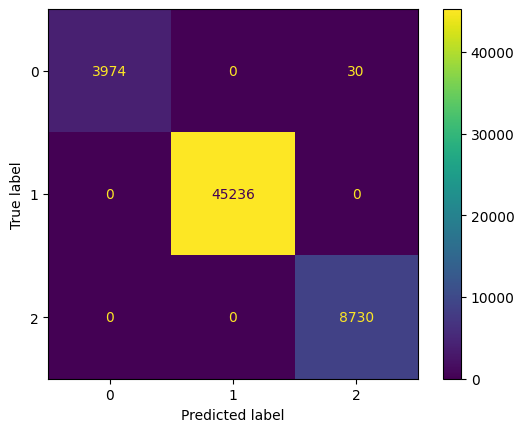

In [12]:
# confusion matrix for Random Forest

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

print("Confusion Matrix (Random Forest)")

## Feature Importance Analysis

Understanding which features influence the model predictions the most using Random Forest.

In [10]:
# feature importance using Random Forest

import pandas as pd

print("calculating feature importance...")

# getting importance values
importances = rf.feature_importances_

# getting feature names (important)
feature_names = df.drop("loanriskcategory", axis=1).columns

# creating dataframe
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# sorting
feature_importance_df = feature_importance_df.sort_values(
    by="importance", ascending=False
)

print("top features:")
print(feature_importance_df.head(10))

calculating feature importance...
top features:
             feature  importance
5                dti    0.585272
0        creditscore    0.367174
12  monthsdelinquent    0.007177
7                ltv    0.005183
11    everdelinquent    0.004914
2                mip    0.004754
15   delinquencyflag    0.004456
4              ocltv    0.004001
6            origupb    0.003163
8   originterestrate    0.002698


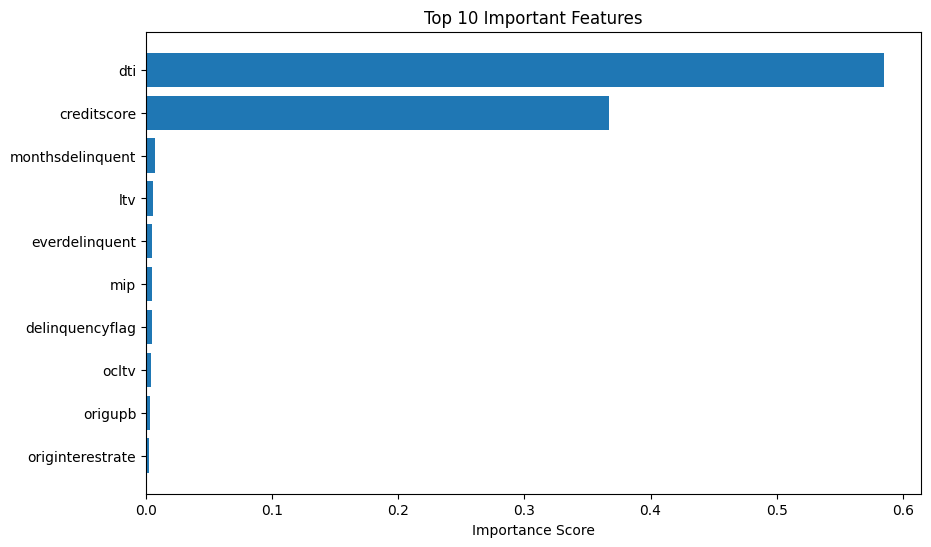

In [9]:
# plotting feature importance

import matplotlib.pyplot as plt

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")

plt.show()

## Final Observations and Insights

### Model Performance

- Random Forest achieved extremely high accuracy (~99.95%), clearly outperforming other models.
- Logistic Regression performed reasonably well (~90%) but could not capture complex relationships.
- SVC (Linear) showed lower performance (~88%), due to linear limitations.

### Advanced Evaluation Insights

- The confusion matrix shows that Random Forest correctly classifies almost all samples across all classes.
- The ROC curve indicates strong model performance and good class separation ability.

### Feature Importance Insights

- DTI (Debt-to-Income ratio) is the most dominant feature (~0.58 importance).
- Credit Score is the second most important feature (~0.36 importance).
- Other features contribute minimally, indicating strong dependence on key financial variables.

### Key Understanding

- Loan risk is primarily driven by borrower financial health.
- Tree-based models like Random Forest are highly effective for capturing non-linear relationships in financial data.

### Important Observation

- The extremely high accuracy suggests potential overfitting.
- Additional validation (cross-validation or unseen data testing) would be required in real-world deployment.

### Practical Conclusion

- Random Forest is the best-performing model for this problem.
- Feature importance improves interpretability and decision-making.
- The model is strong but requires validation before production use.

## Final Project Summary

This project was focused on building a complete machine learning pipeline to predict loan risk categories using a large real-world mortgage dataset.

### Data Handling and Preparation

The dataset contained around 2.9 lakh records with more than 30 features related to borrower financial details and loan characteristics.

- Removed unnecessary columns like IDs
- Selected only relevant numerical features for modeling
- Handled missing values using median imputation
- Standardized features using scaling to ensure consistency across models

This step was important to make the dataset clean, usable, and suitable for machine learning models.

---

### Exploratory Data Analysis (EDA)

Initial analysis was performed to understand how different variables behave and relate to loan risk:

- Credit score distribution showed variation across borrowers
- Loan risk categories were not evenly distributed
- Relationships like loan amount vs DTI were explored
- Boxplots helped identify differences in features across risk categories
- Correlation heatmap showed limited but meaningful relationships

This helped in forming an intuition about which features might influence predictions.

---

### Model Building and Training

Three different models were trained and compared:

- Logistic Regression (baseline linear model)
- Support Vector Machine (Linear SVC for scalability)
- Random Forest (tree-based model)

The dataset was split into training and testing sets (80-20 split), and all models were trained on the same data for fair comparison.

---

### Model Performance

The models showed clear differences in performance:

- Logistic Regression achieved around **90% accuracy**
- SVC achieved around **88% accuracy**
- Random Forest achieved around **99.95% accuracy**

Random Forest clearly outperformed the other models, indicating that the dataset contains complex, non-linear relationships.

---

### Advanced Evaluation

Further evaluation was done using:

- **Confusion Matrix** → showed near-perfect classification for Random Forest
- **ROC Curve** → confirmed strong predictive capability and class separation

These evaluations validated that the model is highly effective on the given dataset.

---

### Feature Importance Analysis

Feature importance from Random Forest revealed that:

- **DTI (Debt-to-Income ratio)** is the most influential feature (~0.58)
- **Credit Score** is the second most important (~0.36)
- All other features have very low importance

This shows that loan risk prediction is heavily dependent on borrower financial health.

---

### Key Insights

- Borrowers with higher DTI are more likely to fall into higher risk categories
- Credit score plays a major role in determining loan reliability
- Only a few features dominate predictions, while others have minor influence
- Tree-based models are better suited for financial datasets with complex interactions

---

### Final Conclusion

The project successfully demonstrates how machine learning can be applied to predict loan risk using real-world data.

Random Forest emerged as the best-performing model due to its ability to capture non-linear relationships and provide feature-level insights.

However, the extremely high accuracy also indicates that the model may be overfitting, and further validation would be required before deploying it in real-world systems.

Overall, this project provides a strong and practical foundation for building scalable financial risk prediction solutions.